In [2]:
import xarray
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

## TEST NDVI

In [ ]:
# test NDVI

def test_ndvi(x: str, y: str) -> None:
    data_path = os.path.join(x, 'output_new', y)
    ds = xarray.open_dataset(data_path)
    return ds
def plot_ndvi(ds) -> None:
    ndvi = ds['Band1']
    ndvi.plot(cmap='YlGn')
    return

x = '/data/dv-data/ndvi/'
y = 'METOP_AVHRR_20250111_S10_AFR_ndvi_psdc.nc'
# y1 = 'METOP_AVHRR_20100111_S10_AFR_ndvi_psdc.nc'

ds = test_ndvi(x, y)
print(ds)
# ds2 = test_ndvi(x, y1)
# test_ndvi(x, y)
# print the matrix values of Band1
print(ds['Band1'].values)
# print(ds2['Band1'].values)

In [ ]:
# test NDVI

def test_ndvi(x: str, y: str) -> None:
    data_path = os.path.join(x, 'output_try_calib', y)
    ds = xarray.open_dataset(data_path)
    return ds
def plot_ndvi(ds) -> None:
    ndvi = ds['Band1']
    ndvi.plot(cmap='YlGn')
    return

x = '/data/dv-data/ndvi/'
y = 'METOP_AVHRR_20100101_S10_AFR_ndvi_psdc.nc'
# y1 = 'METOP_AVHRR_20100111_S10_AFR_ndvi_psdc.nc'

ds = test_ndvi(x, y)
# ds2 = test_ndvi(x, y1)
# test_ndvi(x, y)
# print the matrix values of Band1
print(ds['Band1'].values)
# print(ds2['Band1'].values)

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ds['Band1'].squeeze().plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=-1, vmax=1)
ax.set_title('NDVI Data (2010-01-01)')
plt.tight_layout()
plt.show()

## TEST PRE_PROCESSING

In [10]:
# file_old = "/data/dv-data/raw/era5_data/2010/01/era5_land_2m_temperature_2010_01.nc"
# file_new = r"try/01/NETCDF4_LSASAF_MSG_LST_MSG-Disk_201001010100.nc"
file_new = "/data/dv-data/preprocessed/ndvi/2010/01/01/ndvi_20100101.nc"
# assert os.path.exists(file_old), f"Path {file_old} does not exist"
assert os.path.exists(file_new), f"Path {file_new} does not exist"

# print(f"Path {file_old} exists")
print(f"Path {file_new} exists")

Path /data/dv-data/preprocessed/ndvi/2010/01/01/ndvi_20100101.nc exists


In [11]:
ds = xarray.open_dataset(file_new)
print(ds)

<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 1000, lon: 5800)
Coordinates:
  * lat      (lat) float64 8kB 10.01 10.02 10.03 10.04 ... 19.98 19.98 20.0
  * lon      (lon) float64 46kB -18.0 -17.98 -17.98 -17.96 ... 39.98 39.98 40.0
Data variables:
    Band1    (lat, lon) float32 23MB ...
    crs      |S1 1B ...
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.4.1, released 2021/12/27
    history:      Mon Nov 03 11:14:02 2025: GDAL Create( /data/dv-data/prepro...


In [ ]:
# crs info of ds
print(ds.crs)

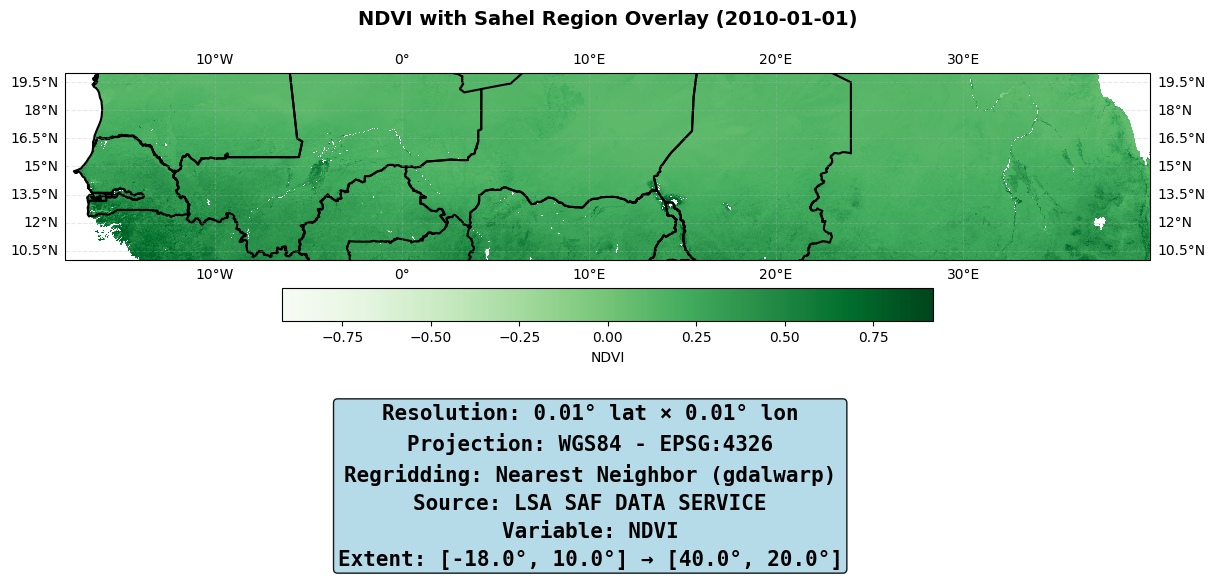

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

# Load shapefile
shapefile = '/data/dv-data/shapefiles/sah_admin0_ocha/sah_admin0_ocha.shp'
reader = shpreader.Reader(shapefile)
sahel_geoms = list(reader.geometries())

# Example dataset attributes (replace with your dataset 'ds')
lat = ds['lat'].values
lon = ds['lon'].values
res_lat = round(np.abs(lat[1] - lat[0]), 3)
res_lon = round(np.abs(lon[1] - lon[0]), 3)

projection = 'WGS84 - EPSG:4326'
regridding_method = 'Nearest Neighbor (gdalwarp)'
data_source = 'LSA SAF DATA SERVICE'
variable = 'NDVI'

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(14, 10))

# Plot data (suppress xarray auto-figure)
data = ds['Band1'].squeeze()
im = data.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap='Greens',
    add_colorbar=False
)

# Add horizontal colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.6)
cbar.set_label(f'{variable}', fontsize=10)

# Add Sahel geometries
sahel = ax.add_geometries(
    sahel_geoms, crs=ccrs.PlateCarree(),
    edgecolor='black', facecolor='none',
    linewidth=1.5, label='Sahel Region'
)

# Gridlines
ax.gridlines(draw_labels=True, alpha=0.3, linestyle='--')

# Title
ax.set_title('NDVI with Sahel Region Overlay (2010-01-01)',
             fontsize=14, fontweight='bold', pad=20)

# Adjust layout so there’s space below the plot
plt.subplots_adjust(top=0.92, bottom=0.22)

# Info box — moved to middle below the plot
info_text = (
    f"Resolution: {res_lat}° lat × {res_lon}° lon\n"
    f"Projection: {projection}\n"
    f"Regridding: {regridding_method}\n"
    f"Source: {data_source}\n"
    f"Variable: {variable}\n"
    f"Extent: [{lon[0]:.1f}°, {lat[0]:.1f}°] → [{lon[-1]:.1f}°, {lat[-1]:.1f}°]"
)

# Add text box centered below the plot
fig.text(
    0.5, 0.21, info_text,
    ha='center', va='top',
    fontsize=15, linespacing=1.5,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9, pad=0.2),
    family='monospace', fontweight='bold'
)

# # Horizontal legend — below the info box
# fig.legend(
#     handles=[sahel],
#     labels=['Sahel Region'],
#     loc='lower center',
#     ncol=3,
#     fontsize=10,
#     frameon=True,
#     framealpha=0.95,
#     bbox_to_anchor=(0.5, 0.05)
# )

plt.show()

fig.savefig('ndvi_sahel_overlay.png', dpi=500, bbox_inches='tight')

In [ ]:
#can we check the resolution of both datasets
lat_old = ds_old['latitude'].values
lon_old = ds_old['longitude'].values
lat_new = ds_new['lat'].values
lon_new = ds_new['lon'].values
res_lat_old = round(np.abs(lat_old[1] - lat_old[0]), 3)
res_lon_old = round(np.abs(lon_old[1] - lon_old[0]), 3)
res_lat_new = round(np.abs(lat_new[1] - lat_new[0]), 3)
res_lon_new = round(np.abs(lon_new[1] - lon_new[0]), 3)
print(f"New dataset resolution: lat {res_lat_new}, lon {res_lon_new}")
print(f"Old dataset resolution: lat {res_lat_old}, lon {res_lon_old}")
print(f"New dataset resolution: lat {res_lat_new}, lon {res_lon_new}")  

In [ ]:
# check number of files in a directory
dir_path = "/data/dv-data/raw/lst_new/2010/10/01"
files = [f for f in os.listdir(dir_path) if f.endswith('.nc')]
print(f"Number of .nc files in {dir_path}: {len(files)}")

In [ ]:
# datatype check
print(f"Old dataset datatype: {ds_old['t2m'].dtype}")
print(f"New dataset datatype: {ds_new['Band1'].dtype}")

In [ ]:
# plot the data to visually inspect it to the extent possible not squeezed
# plot them within african extent
vmin = np.nanmin(ds_new['Band1'].values)
vmax = np.nanmax(ds_new['Band1'].values)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ds_new['Band1'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', vmin=vmin, vmax=vmax)
ax.set_title('Old LST Data (2010-01-01)')
# ax.set_extent([-18.0, 40.0, 10.0, 20.0], crs=ccrs.PlateCarree())
plt.tight_layout()
plt.show()
vmin = np.nanmin(ds_old['t2m'].values)
vmax = np.nanmax(ds_old['t2m'].values)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ds_old['t2m'].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', vmin=vmin, vmax=vmax)
ax.set_title('New LST Data (2010-01-01)')
plt.tight_layout()
plt.show()


